# İş Akışı ve Hiperparametre Optimizasyonu

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

🏠 Ev fiyatları veri setini içe aktarın. Basitlik adına sadece sayısal özellikleri tutacağız

🎯 Hedefiniz en iyi KNN Regressor'ı yerleştirmek olacak. Özellikle, ev fiyatlarınız için en iyi tahminleri elde etmek üzere kaç tane "komşu" (<font color=blue>K</font>NN'deki <font color=blue>K</font>) göz önünde bulundurmalısınız?

In [2]:
# Load raw data
data = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/houses_train_raw.csv', index_col="Id")

# Only keep numerical columns and raws without NaN
data = data.select_dtypes(include=np.number).dropna()

data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


In [3]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

## 1. Eğitim/Test Ayrımı

❓ **Soru (Holdout)**❓

👇 `X_train`, `X_test`, `y_train` ve `y_test` oluşturmak için veri setini böl. Şunları kullan:
- `test_size=0.3`
- Sonuçlarınızı arkadaşınızla karşılaştırmak için `random_state=0`

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(784, 36) (784,)
(337, 36) (337,)


## 2. Ölçeklendirme

⚖️ Ölçeklendirme KNN algoritması için her zaman kritik derecede önemlidir..

❓ **Soru (Ölçeklendirme)** ❓ 

* Eğitim setinizi ve test setinizi ölçeklendirin.
* Burada, basitçe `StandardScaler` uygulayalım ve özellik başına bir ölçekleyici seçerek zaman kaybetmeyelim. Gerçekten de, bu egzersizin amaçları şunlardır:
    * KNN'i gözden geçirmek
    * GridSearchCV'yi anlamak
    * RandomizedSearchCV'yi anlamak

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Temel KNN modeli

❓ **Soru (KNN için bir temel)** ❓

Sadece _en yakın komşuyu_ dikkate alan basit bir KNN regressor'ı çapraz doğrulayın (*cv = 5*) ve 5 kat üzerindeki ortalama skoru hesaplayın.

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

knn_base = KNeighborsRegressor(n_neighbors=1)
base_scores = cross_val_score(knn_base, X_train_scaled, y_train,cv=5)
print(f"Ortalama R2 skoru: {base_scores.mean():.4f}")

Ortalama R2 skoru: 0.5602


## 4. GridSearch

### 4.1. İlk GridSearch

❓ **Soru (GridSearch v1)**❓

En iyi KNN hiperparametresini `n_neighbors` bulmak için SKLearn `GridSearchCV` kullanalım.
- `n_neighbors` = [1,5,10,20,50] ile kaba taneli bir yaklaşım başlat
- Her parametreyi 5-kat çapraz doğrula
- `n_jobs` kullanarak performans sürenizi maksimize ettiğinizden emin olun

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Instantiate model
knn = KNeighborsRegressor()

# Hyperparameter Grid
param_grid = {'n_neighbors': [1, 5, 10, 20, 50]}

# Instantiate Grid Search
grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)

# Fit data to Grid Search
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 5, 10, 20, 50]})

❓ **Soru (en iyi parametreler)** ❓

GridSearch'e göre, optimal K değeri nedir?

In [11]:
print(grid_search.best_params_)

{'n_neighbors': 10}


❓ **Soru (puanlama)** ❓ Optimal K değerinin ürettiği en iyi skor nedir?

In [12]:
print(grid_search.best_score_)

0.7596697382171873


### 4.2. İkinci GridSearch

❓ **Soru (GridSearch V2)** ❓

Şimdi, en iyi $K$'nın nerede olduğu hakkında bir fikrimiz var, ancak denemediğimiz bazı değerler daha iyi bir performansla sonuçlanabilir.

* Önceki en iyi değerinizin çevresindeki $K$ için bazı değerleri deneyerek GridSearch'ü yeniden çalıştırın
* Bu rafine edilmiş GridSearch için `best_score` ve `best_k` nelerdir?

In [15]:
# Instantiate model
knn = KNeighborsRegressor()

# Hyperparameter Grid
param_grid = {'n_neighbors': list(range(5, 30))}

# Instantiate Grid Search
grid_search2 = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)

# Fit data to Grid Search
grid_search2.fit(X_train_scaled, y_train)

best_k = grid_search2.best_params_['n_neighbors']
best_score = grid_search2.best_score_

print(f"best_k = {best_k}, best_score = {best_score:.4f}")

best_k = 16, best_score = 0.7666


***🧪 Kodunuzu test edin***

In [14]:
from nbresult import ChallengeResult
result = ChallengeResult('knn',
                         best_k=best_k,
                         best_score=best_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S-data-workflow/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 2 items

test_knn.py::TestKnn::test_best_k PASSED                                 [ 50%]
test_knn.py::TestKnn::test_best_score PASSED                             [100%]

============================== 2 passed in 0.18s ===============================


💯 You can commit your code:

git add tests/knn.pickle

git commit -m 'Completed knn step'

git push origin master



### 4.3. Görsel kontrol (manuel GridSearch)

☝️ Bu problem aslında manuel olarak GridSearch yapmak için yeterince basittir.

❓ **Soru(Manuel GridSearch)** ❓

- $K$'nın $1$'den $50$'ye kadar tüm değerleri üzerinde manuel olarak döngü yapın ve her modelin çapraz doğrulanmış skorlarının ortalamasını bir listede saklayın.
- `Dirsek Yöntemi` kullanarak en iyi $K$'yı görsel olarak bulmak için skorları $K$'nın bir fonksiyonu olarak çizin

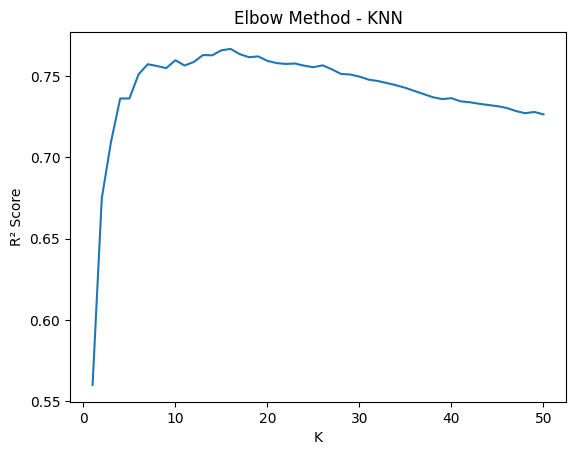

In [16]:
scores = []
k_range = range(1, 51)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    scores.append(cv_scores.mean())

import matplotlib.pyplot as plt
plt.plot(k_range, scores)
plt.xlabel('K')
plt.ylabel('R² Score')
plt.title('Elbow Method - KNN')
plt.show()

❓GridSearchCV'yi böyle bir manuel döngüden daha iyi bir seçenek yapan şeyi tahmin edebilir misiniz?

<details>
    <summary>Cevap</summary>

- Sklearn'ın `n_jobs=-1` seçeneği aramayı paralelleştirmenize izin verir, tüm CPU çekirdeklerinizi kullanır
- Birlikte optimize edilecek birden fazla hiperparametreniz olsaydı ne olurdu?
</details>

## 5. Birden çok parametre ile GridSearch

👩🏻‍🏫 KNNRegressor, `p` hiperparametresi aracılığıyla çeşitli _mesafe metrikleri_ destekler

📚 [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

❓ **Soru (birden çok parametreyi ayarlama)** ❓

* En iyi $K$ ve $p$'yi aynı anda aramak için GridSearchCV kullanın.
    * $K = [1, 5, 10, 20, 50]$ ve $p = [1, 2, 3]$ için tüm kombinasyonları deneyin.

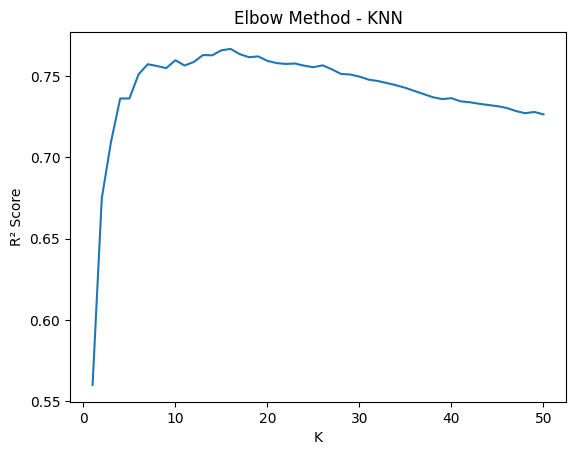

In [17]:
scores = []
k_range = range(1, 51)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    scores.append(cv_scores.mean())

import matplotlib.pyplot as plt
plt.plot(k_range, scores)
plt.xlabel('K')
plt.ylabel('R² Score')
plt.title('Elbow Method - KNN')
plt.show()

❓ **Soru (alt model sayısı)**❓

Toplamda kaç alt model eğittiniz?

<details>
    <summary>İpucu</summary>

15'ten çok daha fazla. İki kez düşün :)
    <details>
    <summary>Cevap</summary>

CV=5 nedeniyle 75 model
</details>

In [18]:
print(5 * 3 * 5)

75


❓ **Soru (modeli birden çok parametre ile ayarladıktan sonra en iyi parametreler ve en iyi skor)**❓

*En iyi parametreler* ve *en iyi skor* nedir?

In [20]:
print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi skor: {grid_search.best_score_:.4f}")

En iyi parametreler: {'n_neighbors': 10}
En iyi skor: 0.7597


## 6. Rastgele Arama

Şimdi bir RandomizedSearch'ün aynı sayıda model yerleştirilerek daha iyi bir kombinasyon bulup bulamayacağını görelim.

❓ **Soru (RandomizedSearchCV)** ❓

`RandomizedSearchCV` kullanarak
- $K$'yı uniform `scipy.stats.randint(1,50)` ([döküman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html)) dağılımından rastgele örnekle
- $p$'yi $[1,2,3]$ listesinden örnekle
- Önceki GridSearchCV'nizdeki ile tam olarak aynı sayıda model yerleştirmek için doğru `n_iter` ve `cv` sayılarını kullanın.

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

knn = KNeighborsRegressor()

param_dist = {
    'n_neighbors': randint(1, 50),
    'p': [1, 2, 3]
}

random_search = RandomizedSearchCV(knn, param_dist, n_iter=15, cv=5, n_jobs=-1, random_state=0)
random_search.fit(X_train_scaled, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_:.4f}")

Best params: {'n_neighbors': 10, 'p': 1}
Best score: 0.7969


## 7. Genelleme

❓ **Soru (modelinizi bir kez daha ince ayarlama)**❓

- İsterseniz RandomsearchCV'nizi rafine edin
- En iyi modelinizi seçin

In [22]:
param_dist_refined = {
    'n_neighbors': randint(5, 30),
    'p': [1, 2, 3]
}

random_search2 = RandomizedSearchCV(knn, param_dist_refined, n_iter=30, cv=5, n_jobs=-1, random_state=0)
random_search2.fit(X_train_scaled, y_train)

print(f"Best params: {random_search2.best_params_}")
print(f"Best score: {random_search2.best_score_:.4f}")

Best params: {'n_neighbors': 7, 'p': 1}
Best score: 0.7950


Şimdi `cv_results`'ınızı bir `DataFrame` olarak görüntülemeye çalışın, bu CV'nin içinde neler olup bittiğini görselleştirmenize yardımcı olacak! 😉

In [23]:
pd.DataFrame(random_search2.cv_results_).sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
25,0.001765,0.000950,0.005266,0.000341,7,1,"{'n_neighbors': 7, 'p': 1}",0.736660,0.817465,0.757978,0.867009,0.795878,0.794998,0.045749,1
26,0.001455,0.000328,0.005849,0.000852,5,1,"{'n_neighbors': 5, 'p': 1}",0.695777,0.817846,0.759819,0.867212,0.823164,0.792764,0.059309,2
28,0.001774,0.000791,0.005939,0.000616,11,1,"{'n_neighbors': 11, 'p': 1}",0.762816,0.815302,0.726084,0.862879,0.795986,0.792613,0.046427,3
19,0.000998,0.000132,0.006540,0.001677,12,1,"{'n_neighbors': 12, 'p': 1}",0.761157,0.813126,0.732005,0.856813,0.790195,0.790659,0.042876,4
12,0.001395,0.000351,0.008122,0.003197,14,1,"{'n_neighbors': 14, 'p': 1}",0.758705,0.812448,0.727145,0.851217,0.777336,0.785370,0.042976,5
11,0.002955,0.002751,0.008784,0.002593,18,1,"{'n_neighbors': 18, 'p': 1}",0.760167,0.806875,0.732038,0.834326,0.770070,0.780695,0.035954,6
15,0.001370,0.000157,0.006870,0.001107,20,1,"{'n_neighbors': 20, 'p': 1}",0.769058,0.809681,0.728546,0.826840,0.761282,0.779081,0.035181,7
3,0.001021,0.000215,0.004932,0.000321,23,1,"{'n_neighbors': 23, 'p': 1}",0.765220,0.810307,0.727123,0.822327,0.759124,0.776820,0.034956,8
16,0.001891,0.000758,0.008035,0.002125,23,1,"{'n_neighbors': 23, 'p': 1}",0.765220,0.810307,0.727123,0.822327,0.759124,0.776820,0.034956,8
13,0.002233,0.002241,0.011055,0.003292,24,1,"{'n_neighbors': 24, 'p': 1}",0.768028,0.808209,0.724827,0.818526,0.762317,0.776381,0.033807,10


❓ **Soru ("En iyi" modelin değerlendirmesi)** ❓

* "En iyi parametrelerle" modelimizin **görülmemiş** test seti `X_test` üzerindeki performansını keşfetme zamanı geldi.
    * Test seti için r2 skorunu hesaplayın ve `r2_test` olarak kaydedin.

In [24]:
best_model = random_search2.best_estimator_
r2_test = best_model.score(X_test_scaled, y_test)
print(f"Test R2: {r2_test:.4f}")

Test R2: 0.7691


❓ **Soru (Bir adım geri çekilme)** ❓

Optimize edilmiş modelin iyi genelleme yaptığını düşünür müsünüz?

<details><summary>Cevap</summary>

Test skoru eğitim seti ile biraz azalabilir. Muhtemelen %5'ten fazla değil. Bunun nedeni şunlar olabilir:
- Temsili olmayan bir eğitim/test bölünmesi
- Model ayarlama aşamasında aşırı öğrenmeye yol açan çok küçük bir çapraz doğrulama sayısı. Ne kadar çok çapraz doğrulama yaparsanız, bulgularınız o kadar güçlü genelleşir - ancak veri setiniz çok küçükse cv'yi çok fazla artıramazsınız çünkü her katmanda temsili olmak için yeterli gözlemi tutamazsınız.
- Veri setimiz çok küçük ve hiperparametre optimizasyonumuz bu nedenle eğitim/test bölünmemize son derece bağımlı (ve aşırı uyum gösteriyor). Veri setinizin denediğiniz toplam hiperparametre kombinasyonu sayısından çok daha büyük olduğundan her zaman emin olun!
    
</details>

***🧪 Kodunuzu test edin***

In [ ]:
from nbresult import ChallengeResult
result = ChallengeResult('r2',
                         r2_test=r2_test)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/ubtuna/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/ubtuna/S-data-workflow/tests
plugins: anyio-4.8.0, typeguard-4.4.2, dash-4.1.0
collecting ... collected 1 item

test_r2.py::TestR2::test_r2 PASSED                                       [100%]

============================== 1 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/r2.pickle

git commit -m 'Completed r2 step'

git push origin master



🏁 Tebrikler! Artık GridSearchCV veya RandomizedSearchCV kullanarak bir modeli nasıl ince ayarlayacağınızı biliyorsunuz

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki meydan okumaya geçin!